In [1]:
import pandas as pd
import numpy as np
import os

DATA_DIR = '/rds/homes/j/jxt554/data'

meta_cd = pd.read_csv(
    f'{DATA_DIR}/meta_cd_final.csv')
meta_uc = pd.read_csv(
    f'{DATA_DIR}/meta_uc_final.csv')

print('CD METADATA:')
print(f'Shape: {meta_cd.shape}')
print(f'Columns: {meta_cd.columns.tolist()}')
print(f'\nCluster distribution:')
print(meta_cd['cluster'].value_counts())
print(f'\nFirst 3 rows:')
print(meta_cd.head(3).to_string())

print('\n\nUC METADATA:')
print(f'Shape: {meta_uc.shape}')
print(f'Columns: {meta_uc.columns.tolist()}')
print(f'\nCluster distribution:')
print(meta_uc['cluster'].value_counts())

CD METADATA:
Shape: (215, 12)
Columns: ['id', 'sex', 'age', 'bmi', 'smoking_status', 'smoking_past', 'hba1c', 'ibd_status', 'diagnosis', 'batch', 'cluster', 'stability']

Cluster distribution:
cluster
1    133
0     82
Name: count, dtype: int64

First 3 rows:
    id  sex  age      bmi smoking_status                smoking_past  hba1c  ibd_status diagnosis  batch  cluster  stability
0  124    1   43  28.5659          Never         I have never smoked   29.1           1        CD      0        0   0.677995
1  357    0   61  24.2533       Previous  Smoked on most or all days   56.5           1        CD      0        1   0.979454
2  474    0   69  23.0915          Never         I have never smoked   30.1           1        CD      0        0   0.677995


UC METADATA:
Shape: (430, 12)
Columns: ['id', 'sex', 'age', 'bmi', 'smoking_status', 'smoking_past', 'hba1c', 'ibd_status', 'diagnosis', 'batch', 'cluster', 'stability']

Cluster distribution:
cluster
0    299
1    131
Name: count, dtype:

In [3]:
# ============================================================
# 06_biological_characterisation.py
# 5.1 Clinical char + 5.2 Sample distribution
# + 5.3 Model quality
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore')
import os

PROJECT_DIR  = '/rds/homes/j/jxt554'
DATA_DIR     = f'{PROJECT_DIR}/data'
FIGURES_DIR  = f'{PROJECT_DIR}/figures'
TABLES_DIR   = f'{PROJECT_DIR}/tables'
SEED         = 42

X_cd      = np.load(f'{DATA_DIR}/X_cd_int.npy')
X_uc      = np.load(f'{DATA_DIR}/X_uc_int.npy')
cd_cons   = np.load(
    f'{DATA_DIR}/consensus_matrix_cd.npy')
uc_cons   = np.load(
    f'{DATA_DIR}/consensus_matrix_uc.npy')
cd_stab   = np.load(f'{DATA_DIR}/stability_cd.npy')
uc_stab   = np.load(f'{DATA_DIR}/stability_uc.npy')
meta_cd   = pd.read_csv(
    f'{DATA_DIR}/meta_cd_final.csv')
meta_uc   = pd.read_csv(
    f'{DATA_DIR}/meta_uc_final.csv')

PALETTE   = {0:'#2E7D5B', 1:'#D97B2E'}
C_NAMES   = {0:'C1', 1:'C2'}

print('PHASE 5 — BIOLOGICAL CHARACTERISATION')
print('='*55)
print(f'CD: {len(meta_cd)} patients | '
      f'k={meta_cd["cluster"].nunique()}')
print(f'UC: {len(meta_uc)} patients | '
      f'k={meta_uc["cluster"].nunique()}')
print(f'\nCD cluster sizes:')
print(meta_cd['cluster'].value_counts())
print(f'\nUC cluster sizes:')
print(meta_uc['cluster'].value_counts())

PHASE 5 — BIOLOGICAL CHARACTERISATION
CD: 215 patients | k=2
UC: 430 patients | k=2

CD cluster sizes:
cluster
1    133
0     82
Name: count, dtype: int64

UC cluster sizes:
cluster
0    299
1    131
Name: count, dtype: int64


In [4]:
# ── 5.1 + 5.2: Clinical char + distribution ────────
def clinical_characterisation(
        meta, cohort, palette=PALETTE):

    print(f'\n{cohort} CLINICAL CHARACTERISATION')
    print('='*55)

    K       = meta['cluster'].nunique()
    results = []

    # ── Continuous variables ──────────────────────
    cont_vars = {
        'age'  : 'Age (years)',
        'bmi'  : 'BMI',
        'hba1c': 'HbA1c (mmol/mol)',
    }

    # Add CRP/calprotectin if available
    for col in ['crp','calprotectin',
                 'crp_mg_l','disease_duration']:
        if col in meta.columns:
            cont_vars[col] = col.upper()

    print('\nContinuous variables:')
    for var, label in cont_vars.items():
        if var not in meta.columns:
            continue
        groups = [
            meta.loc[meta['cluster']==c,
                      var].dropna()
            for c in range(K)]
        if K == 2:
            stat, p = stats.mannwhitneyu(
                groups[0], groups[1],
                alternative='two-sided')
            test = 'Mann-Whitney U'
        else:
            stat, p = stats.kruskal(*groups)
            test = 'Kruskal-Wallis'
        sig = ('**' if p<0.01 else
               ('*' if p<0.05 else 'ns'))
        print(f'\n  {label} ({test}):')
        for c in range(K):
            g = groups[c]
            print(f'    C{c+1}: '
                  f'mean={g.mean():.2f} '
                  f'sd={g.std():.2f} '
                  f'median={g.median():.2f}')
        print(f'    p={p:.4f} {sig}')
        results.append({
            'cohort'  : cohort,
            'variable': label,
            'test'    : test,
            'p_value' : round(p, 4),
            'sig'     : sig})

    # ── Categorical variables ─────────────────────
    cat_vars = {
        'sex'           : 'Sex',
        'batch'         : 'Batch (panel)',
        'smoking_status': 'Smoking',
    }
    for col in ['treatment','biologic',
                 'treatment_escalation',
                 'surgery']:
        if col in meta.columns:
            cat_vars[col] = col.replace('_',' ').title()

    print('\nCategorical variables:')
    for var, label in cat_vars.items():
        if var not in meta.columns:
            continue
        ct  = pd.crosstab(
            meta['cluster'], meta[var])
        chi2, p, dof, _ = \
            stats.chi2_contingency(ct)
        sig = ('**' if p<0.01 else
               ('*' if p<0.05 else 'ns'))
        print(f'\n  {label} (Chi-squared):')
        for c in range(K):
            mask = meta['cluster']==c
            n_c  = mask.sum()
            vals = meta.loc[mask, var]\
                       .value_counts()
            print(f'    C{c+1} (n={n_c}): '
                  f'{vals.to_dict()}')
        print(f'    p={p:.4f} {sig}')
        results.append({
            'cohort'  : cohort,
            'variable': label,
            'test'    : 'Chi-squared',
            'p_value' : round(p, 4),
            'sig'     : sig})

    res_df = pd.DataFrame(results)
    res_df.to_csv(
        f'{TABLES_DIR}/'
        f'clinical_char_{cohort.lower()}.csv',
        index=False)

    print(f'\nSIGNIFICANT FINDINGS:')
    sig_df = res_df[res_df['p_value'] < 0.05]
    if len(sig_df) > 0:
        print(sig_df[['variable',
                       'p_value',
                       'sig']].to_string(
            index=False))
    else:
        print('  None — subtypes are '
              'molecularly not demographically '
              'defined')

    return res_df

cd_clin = clinical_characterisation(
    meta_cd, 'CD')
uc_clin = clinical_characterisation(
    meta_uc, 'UC')


CD CLINICAL CHARACTERISATION

Continuous variables:

  Age (years) (Mann-Whitney U):
    C1: mean=56.50 sd=7.74 median=58.00
    C2: mean=56.03 sd=8.50 median=58.00
    p=0.7432 ns

  BMI (Mann-Whitney U):
    C1: mean=26.85 sd=4.58 median=26.65
    C2: mean=26.41 sd=4.41 median=25.98
    p=0.6140 ns

  HbA1c (mmol/mol) (Mann-Whitney U):
    C1: mean=36.47 sd=7.22 median=35.30
    C2: mean=36.67 sd=10.28 median=34.60
    p=0.2157 ns

Categorical variables:

  Sex (Chi-squared):
    C1 (n=82): {1: 48, 0: 34}
    C2 (n=133): {0: 77, 1: 56}
    p=0.0277 *

  Batch (panel) (Chi-squared):
    C1 (n=82): {0: 72, 1: 10}
    C2 (n=133): {0: 117, 1: 16}
    p=1.0000 ns

  Smoking (Chi-squared):
    C1 (n=82): {'Previous': 33, 'Never': 32, 'Current': 17}
    C2 (n=133): {'Never': 65, 'Previous': 50, 'Current': 18}
    p=0.2470 ns

SIGNIFICANT FINDINGS:
variable  p_value sig
     Sex   0.0277   *

UC CLINICAL CHARACTERISATION

Continuous variables:

  Age (years) (Mann-Whitney U):
    C1: mean=5

✓ Saved: clinical_char_cd.png
✓ Saved: clinical_char_uc.png

clinical_char_cd.png (367 KB):


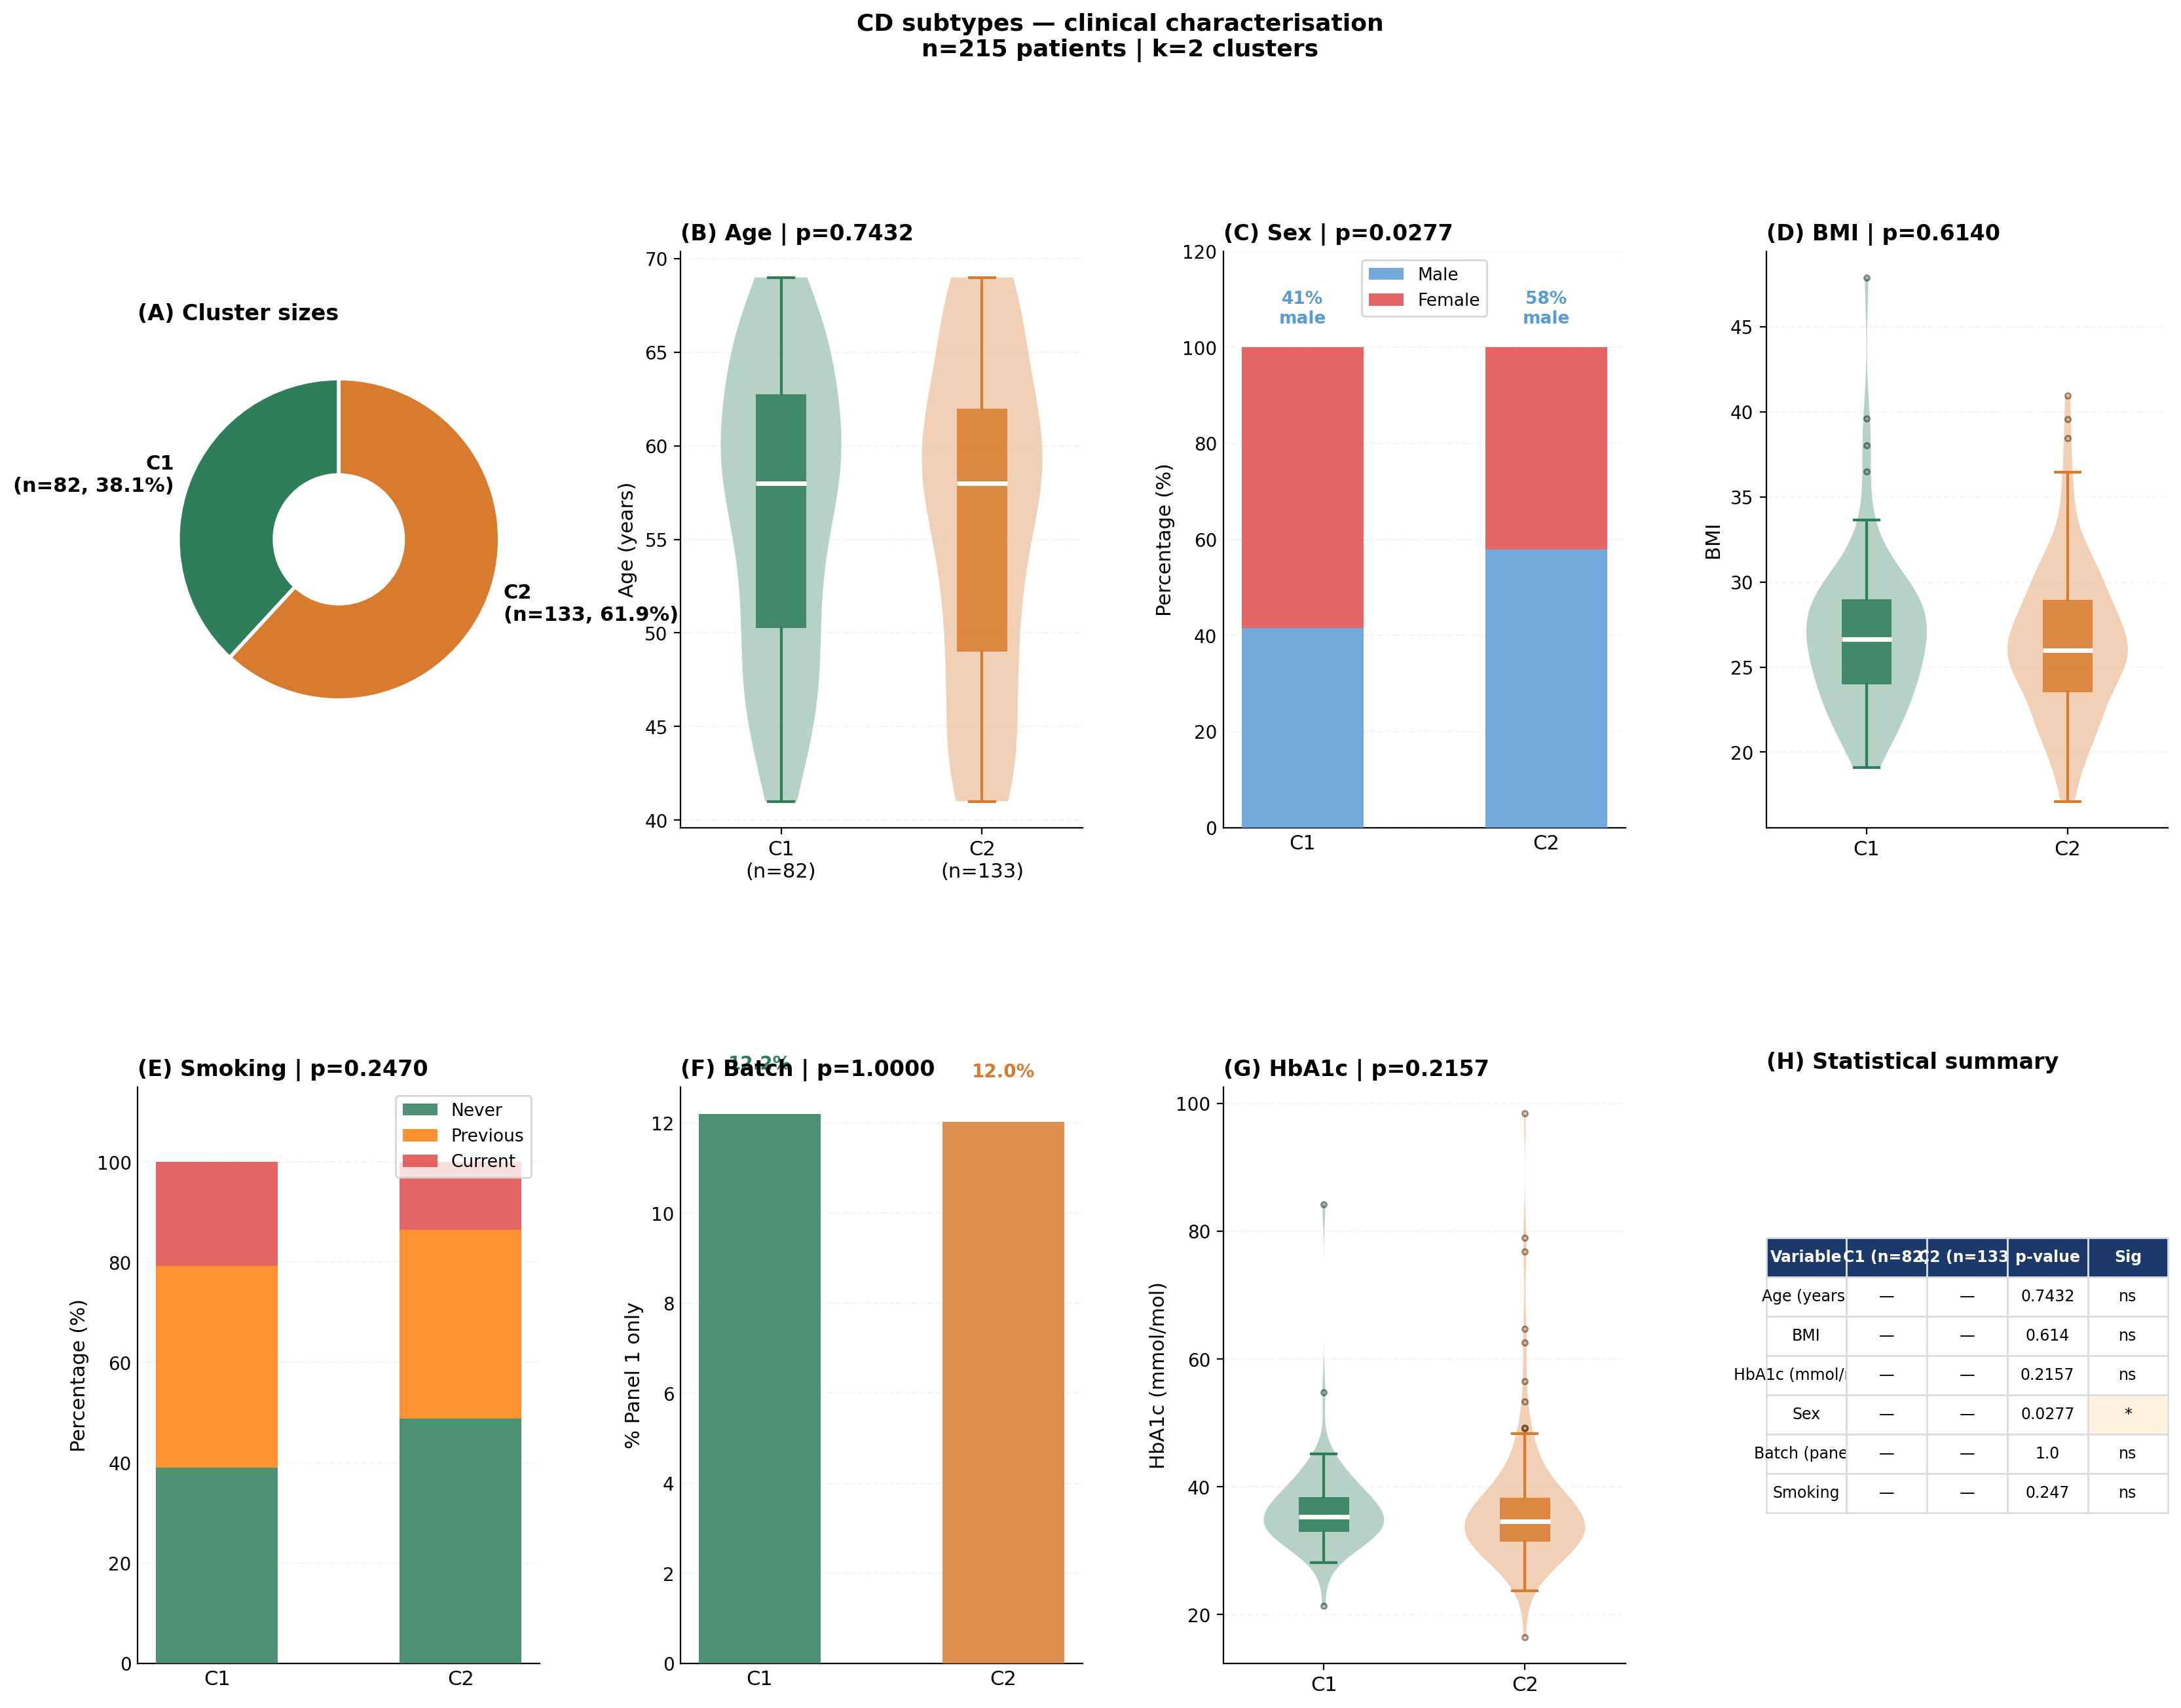


clinical_char_uc.png (388 KB):


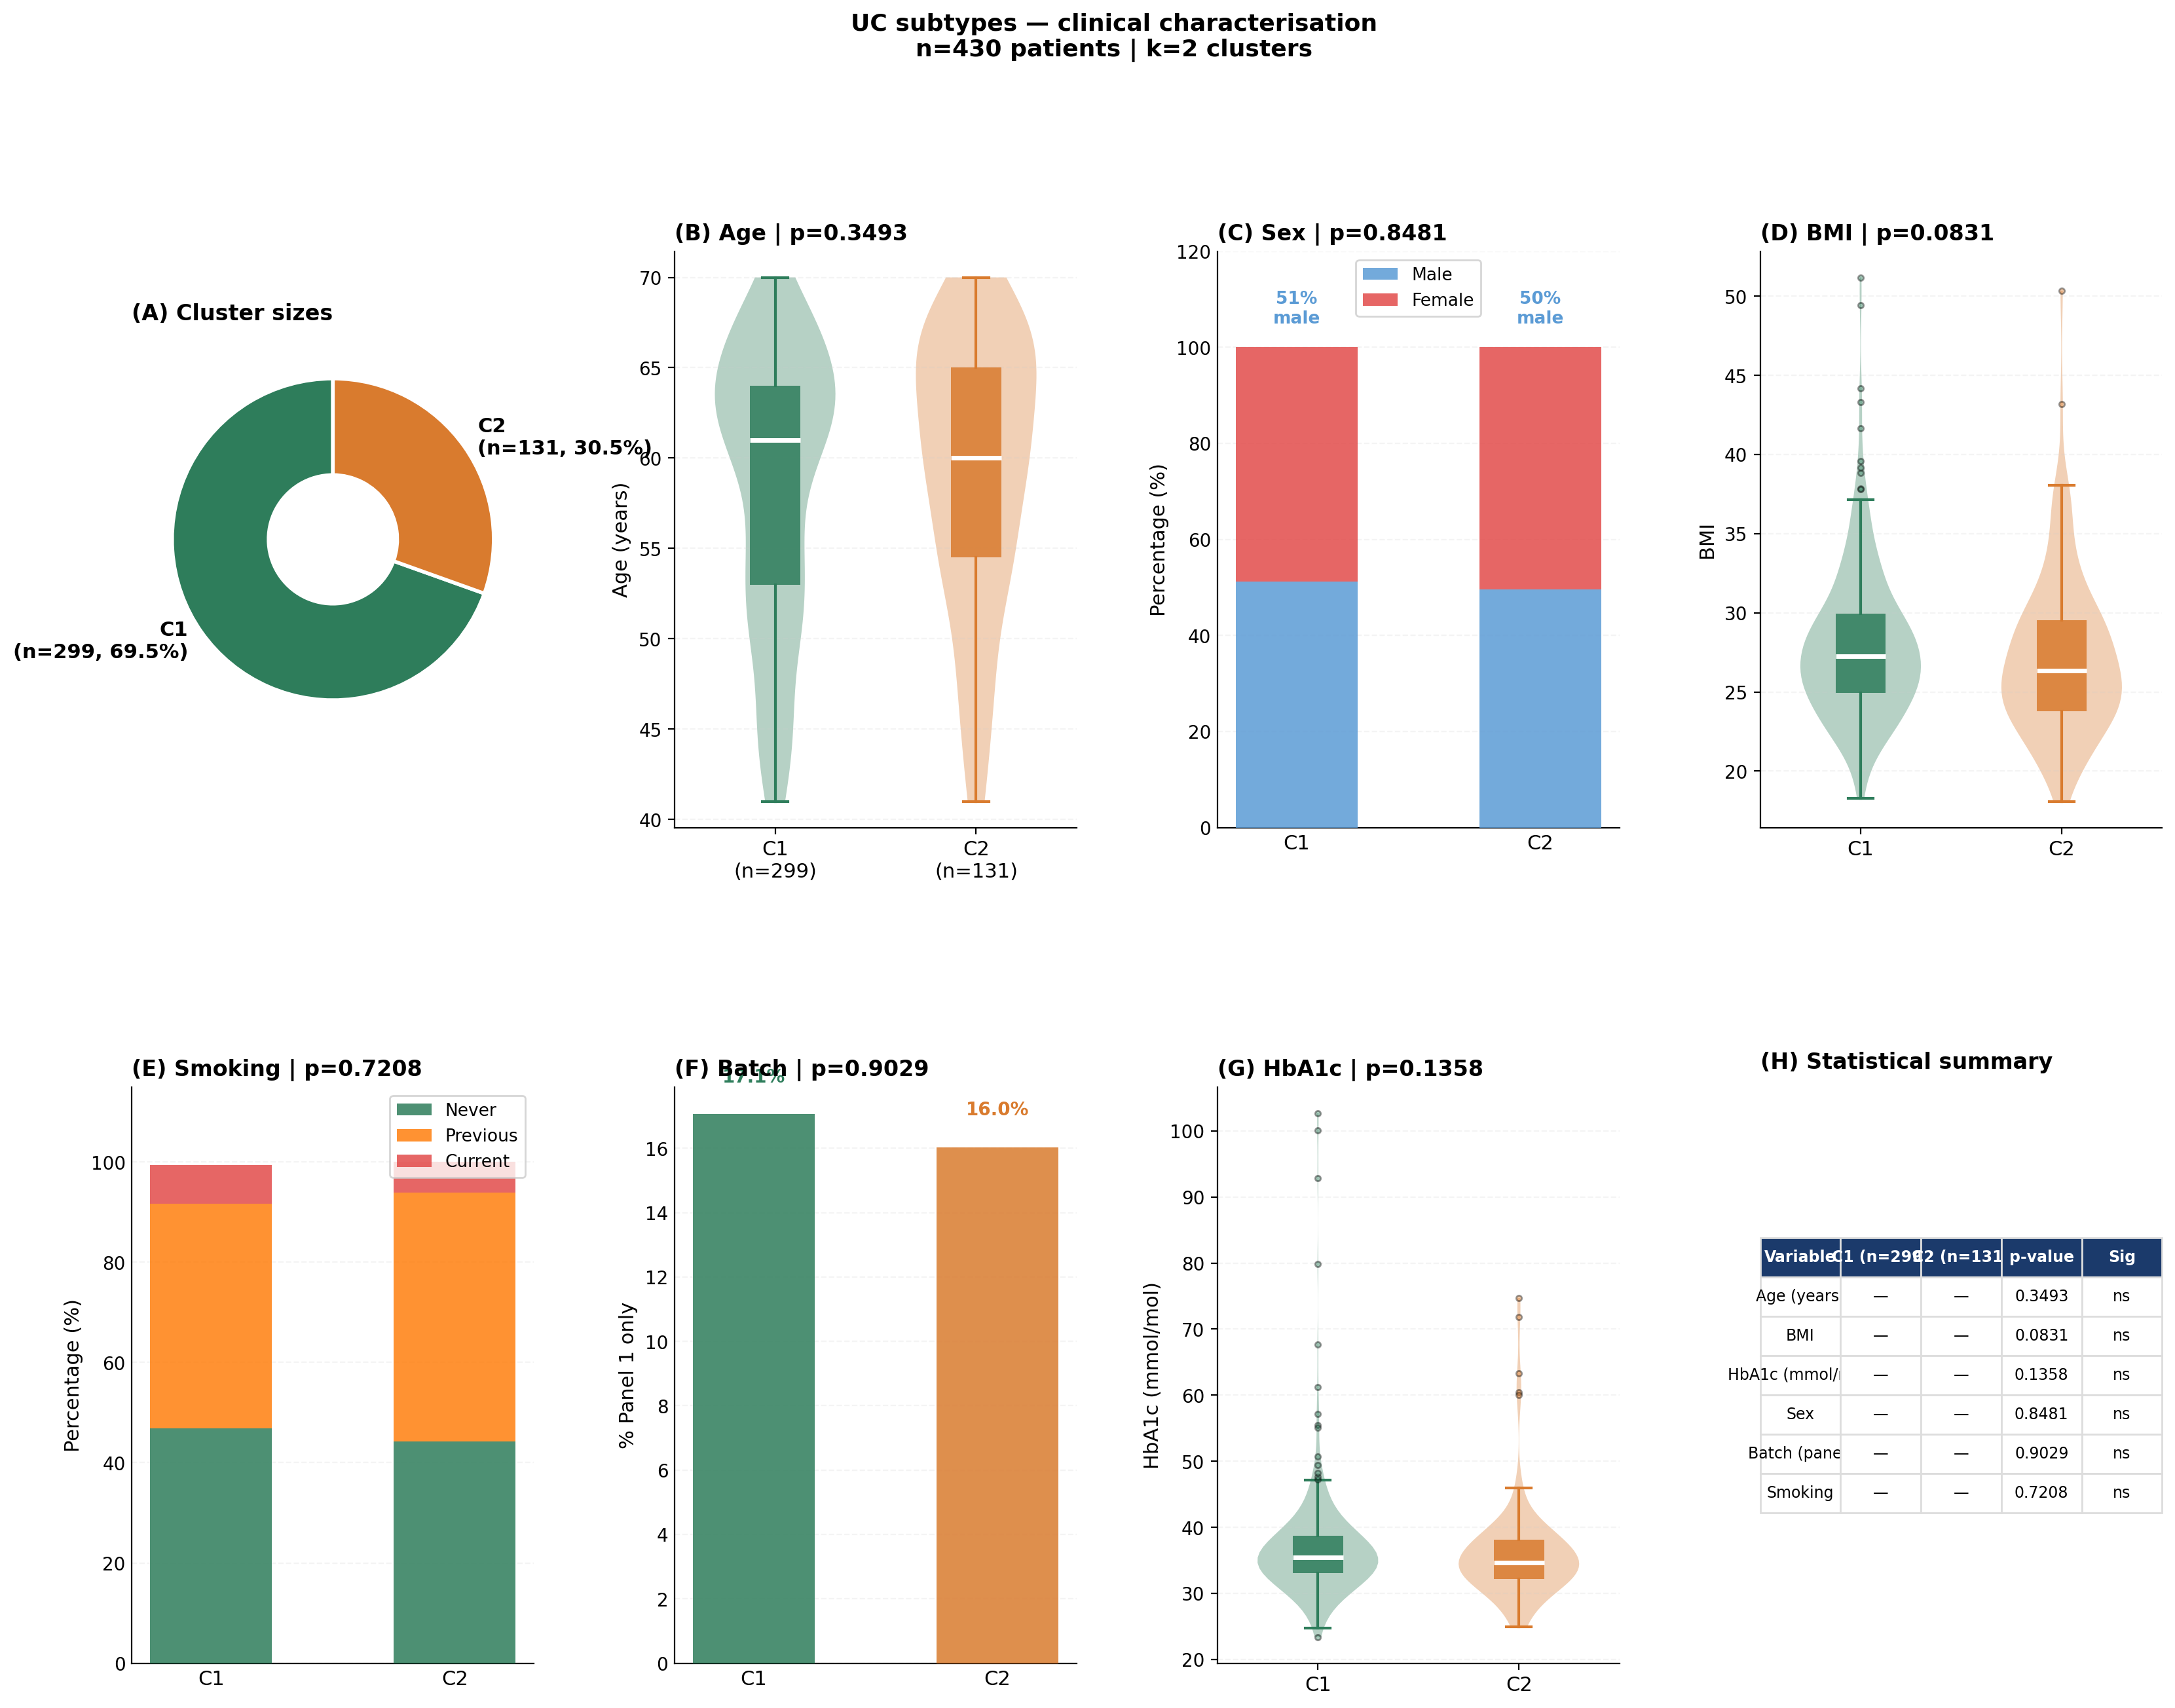

In [5]:
# ── 5.2: Sample distribution figure ───────────────
def plot_sample_distribution(
        meta, cohort, palette=PALETTE):

    K    = meta['cluster'].nunique()
    N    = len(meta)
    fig  = plt.figure(figsize=(20, 14))
    fig.patch.set_facecolor('white')
    gs   = gridspec.GridSpec(
        2, 4, figure=fig,
        hspace=0.45, wspace=0.35)

    # A: Cluster sizes pie
    ax = fig.add_subplot(gs[0,0])
    ax.set_facecolor('white')
    sizes  = [( meta['cluster']==c).sum()
               for c in range(K)]
    labels = [f'C{c+1}\n(n={s}, '
               f'{s/N*100:.1f}%)'
               for c,s in enumerate(sizes)]
    colors = [palette[c] for c in range(K)]
    wedges, texts = ax.pie(
        sizes, labels=labels,
        colors=colors, startangle=90,
        wedgeprops=dict(
            width=0.6, edgecolor='white',
            linewidth=2),
        textprops=dict(fontsize=11,
                        fontweight='700'))
    ax.set_title(
        '(A) Cluster sizes',
        fontsize=12, fontweight='700',
        loc='left', pad=10)

    # B: Age violin
    ax = fig.add_subplot(gs[0,1])
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2,
            linestyle='--', color='#ccc')
    for c in range(K):
        vals  = meta.loc[
            meta['cluster']==c, 'age']
        parts = ax.violinplot(
            vals, positions=[c],
            showmedians=False,
            showextrema=False,
            widths=0.6)
        for pc in parts['bodies']:
            pc.set_facecolor(palette[c])
            pc.set_alpha(0.35)
        ax.boxplot(
            vals, positions=[c],
            widths=0.25,
            patch_artist=True,
            medianprops=dict(
                color='white', linewidth=2.5),
            boxprops=dict(
                facecolor=palette[c],
                alpha=0.85, linewidth=0),
            whiskerprops=dict(
                color=palette[c],
                linewidth=1.5),
            capprops=dict(
                color=palette[c],
                linewidth=1.5),
            flierprops=dict(
                marker='o',
                markerfacecolor=palette[c],
                markersize=3, alpha=0.4))
    p_age = cd_clin[
        cd_clin['variable']=='Age (years)'
    ]['p_value'].values[0] \
        if cohort=='CD' \
        else uc_clin[
        uc_clin['variable']=='Age (years)'
    ]['p_value'].values[0]
    ax.set_xticks(range(K))
    ax.set_xticklabels(
        [f'C{c+1}\n(n={( meta["cluster"]==c).sum()})'
         for c in range(K)],
        fontsize=11)
    ax.set_ylabel('Age (years)', fontsize=11)
    ax.set_title(
        f'(B) Age | p={p_age:.4f}',
        fontsize=12, fontweight='700',
        loc='left')

    # C: Sex stacked bar
    ax = fig.add_subplot(gs[0,2])
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2,
            linestyle='--', color='#ccc')
    ax.tick_params(length=0)
    for c in range(K):
        mask = meta['cluster']==c
        n_c  = mask.sum()
        n_m  = (meta.loc[mask,'sex']==0).sum()
        n_f  = n_c - n_m
        ax.bar(c, n_m/n_c*100,
                color='#5B9BD5', alpha=0.85,
                width=0.5, zorder=3)
        ax.bar(c, n_f/n_c*100,
                bottom=n_m/n_c*100,
                color='#E24B4A', alpha=0.85,
                width=0.5, zorder=3)
        ax.text(c, 105,
                 f'{n_m/n_c*100:.0f}%\nmale',
                 ha='center', fontsize=9.5,
                 fontweight='600',
                 color='#5B9BD5')
    ax.set_xticks(range(K))
    ax.set_xticklabels(
        [f'C{c+1}' for c in range(K)],
        fontsize=11)
    ax.set_ylabel('Percentage (%)', fontsize=11)
    ax.set_ylim(0, 120)
    p_sex = cd_clin[
        cd_clin['variable']=='Sex'
    ]['p_value'].values[0] \
        if cohort=='CD' \
        else uc_clin[
        uc_clin['variable']=='Sex'
    ]['p_value'].values[0]
    ax.set_title(
        f'(C) Sex | p={p_sex:.4f}',
        fontsize=12, fontweight='700',
        loc='left')
    ax.legend(handles=[
        Patch(facecolor='#5B9BD5',
               alpha=0.85, label='Male'),
        Patch(facecolor='#E24B4A',
               alpha=0.85, label='Female')],
        fontsize=9.5)

    # D: BMI violin
    ax = fig.add_subplot(gs[0,3])
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2,
            linestyle='--', color='#ccc')
    if 'bmi' in meta.columns:
        for c in range(K):
            vals  = meta.loc[
                meta['cluster']==c,
                'bmi'].dropna()
            parts = ax.violinplot(
                vals, positions=[c],
                showmedians=False,
                showextrema=False,
                widths=0.6)
            for pc in parts['bodies']:
                pc.set_facecolor(palette[c])
                pc.set_alpha(0.35)
            ax.boxplot(
                vals, positions=[c],
                widths=0.25,
                patch_artist=True,
                medianprops=dict(
                    color='white',
                    linewidth=2.5),
                boxprops=dict(
                    facecolor=palette[c],
                    alpha=0.85,
                    linewidth=0),
                whiskerprops=dict(
                    color=palette[c],
                    linewidth=1.5),
                capprops=dict(
                    color=palette[c],
                    linewidth=1.5),
                flierprops=dict(
                    marker='o',
                    markerfacecolor=palette[c],
                    markersize=3,
                    alpha=0.4))
        p_bmi = cd_clin[
            cd_clin['variable']=='BMI'
        ]['p_value'].values[0] \
            if cohort=='CD' \
            else uc_clin[
            uc_clin['variable']=='BMI'
        ]['p_value'].values[0]
        ax.set_xticks(range(K))
        ax.set_xticklabels(
            [f'C{c+1}' for c in range(K)],
            fontsize=11)
        ax.set_ylabel('BMI', fontsize=11)
        ax.set_title(
            f'(D) BMI | p={p_bmi:.4f}',
            fontsize=12, fontweight='700',
            loc='left')

    # E: Smoking stacked bar
    ax = fig.add_subplot(gs[1,0])
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2,
            linestyle='--', color='#ccc')
    ax.tick_params(length=0)
    if 'smoking_status' in meta.columns:
        cats    = ['Never','Previous','Current']
        colors_s = ['#2E7D5B','#ff7f0e',
                     '#E24B4A']
        bottoms = np.zeros(K)
        for cat, col in zip(cats, colors_s):
            vals = []
            for c in range(K):
                mask = meta['cluster']==c
                n_c  = mask.sum()
                n_s  = (meta.loc[
                    mask,'smoking_status'
                ]==cat).sum()
                vals.append(n_s/n_c*100)
            ax.bar(range(K), vals,
                    bottom=bottoms,
                    color=col, alpha=0.85,
                    width=0.5, zorder=3,
                    label=cat)
            bottoms += np.array(vals)
        ax.set_xticks(range(K))
        ax.set_xticklabels(
            [f'C{c+1}' for c in range(K)],
            fontsize=11)
        ax.set_ylabel('Percentage (%)',
                       fontsize=11)
        ax.set_ylim(0, 115)
        p_sm = cd_clin[
            cd_clin['variable']=='Smoking'
        ]['p_value'].values[0] \
            if cohort=='CD' \
            else uc_clin[
            uc_clin['variable']=='Smoking'
        ]['p_value'].values[0]
        ax.set_title(
            f'(E) Smoking | p={p_sm:.4f}',
            fontsize=12, fontweight='700',
            loc='left')
        ax.legend(fontsize=9.5)

    # F: Batch bar
    ax = fig.add_subplot(gs[1,1])
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2,
            linestyle='--', color='#ccc')
    ax.tick_params(length=0)
    if 'batch' in meta.columns:
        for c in range(K):
            mask = meta['cluster']==c
            n_c  = mask.sum()
            n_b1 = (meta.loc[
                mask,'batch']==1).sum()
            ax.bar(c, n_b1/n_c*100,
                    color=palette[c],
                    alpha=0.85, width=0.5,
                    zorder=3)
            ax.text(c, n_b1/n_c*100+1,
                     f'{n_b1/n_c*100:.1f}%',
                     ha='center', fontsize=10,
                     fontweight='700',
                     color=palette[c])
        p_bat = cd_clin[
            cd_clin['variable']==
            'Batch (panel)'
        ]['p_value'].values[0] \
            if cohort=='CD' \
            else uc_clin[
            uc_clin['variable']==
            'Batch (panel)'
        ]['p_value'].values[0]
        ax.set_xticks(range(K))
        ax.set_xticklabels(
            [f'C{c+1}' for c in range(K)],
            fontsize=11)
        ax.set_ylabel('% Panel 1 only',
                       fontsize=11)
        ax.set_title(
            f'(F) Batch | p={p_bat:.4f}',
            fontsize=12, fontweight='700',
            loc='left')

    # G: HbA1c violin
    ax = fig.add_subplot(gs[1,2])
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2,
            linestyle='--', color='#ccc')
    if 'hba1c' in meta.columns:
        for c in range(K):
            vals  = meta.loc[
                meta['cluster']==c,
                'hba1c'].dropna()
            if len(vals) < 3:
                continue
            parts = ax.violinplot(
                vals, positions=[c],
                showmedians=False,
                showextrema=False,
                widths=0.6)
            for pc in parts['bodies']:
                pc.set_facecolor(palette[c])
                pc.set_alpha(0.35)
            ax.boxplot(
                vals, positions=[c],
                widths=0.25,
                patch_artist=True,
                medianprops=dict(
                    color='white',
                    linewidth=2.5),
                boxprops=dict(
                    facecolor=palette[c],
                    alpha=0.85,
                    linewidth=0),
                whiskerprops=dict(
                    color=palette[c],
                    linewidth=1.5),
                capprops=dict(
                    color=palette[c],
                    linewidth=1.5),
                flierprops=dict(
                    marker='o',
                    markerfacecolor=palette[c],
                    markersize=3,
                    alpha=0.4))
        p_hba = cd_clin[
            cd_clin['variable']==
            'HbA1c (mmol/mol)'
        ]['p_value'].values[0] \
            if cohort=='CD' \
            else uc_clin[
            uc_clin['variable']==
            'HbA1c (mmol/mol)'
        ]['p_value'].values[0]
        ax.set_xticks(range(K))
        ax.set_xticklabels(
            [f'C{c+1}' for c in range(K)],
            fontsize=11)
        ax.set_ylabel('HbA1c (mmol/mol)',
                       fontsize=11)
        ax.set_title(
            f'(G) HbA1c | p={p_hba:.4f}',
            fontsize=12, fontweight='700',
            loc='left')

    # H: Summary table
    ax = fig.add_subplot(gs[1,3])
    ax.set_facecolor('white')
    ax.axis('off')

    # Build summary
    rows  = []
    cols  = ['Variable'] + \
            [f'C{c+1} (n={(meta["cluster"]==c).sum()})'
             for c in range(K)] + \
            ['p-value','Sig']
    for _, row in (cd_clin if cohort=='CD'
                    else uc_clin).iterrows():
        var = row['variable']
        if var not in meta.columns and \
                var not in [
                    'Age (years)','BMI',
                    'HbA1c (mmol/mol)',
                    'Sex','Batch (panel)',
                    'Smoking']:
            continue
        rows.append([
            var,
            *['—']*K,
            str(row['p_value']),
            row['sig']])

    if rows:
        tbl = ax.table(
            cellText=rows,
            colLabels=cols,
            loc='center',
            cellLoc='center')
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(8.5)
        tbl.scale(1.0, 1.8)
        for (r,c), cell in tbl.get_celld().items():
            if r == 0:
                cell.set_facecolor('#1B3A6B')
                cell.set_text_props(
                    color='white',
                    fontweight='700')
            elif c == len(cols)-1:
                sig_val = cell.get_text().get_text()
                if '**' in sig_val:
                    cell.set_facecolor('#FFE0E0')
                elif '*' in sig_val:
                    cell.set_facecolor('#FFF3E0')
            cell.set_edgecolor('#DDDDDD')

    ax.set_title(
        '(H) Statistical summary',
        fontsize=12, fontweight='700',
        loc='left', pad=10)

    plt.suptitle(
        f'{cohort} subtypes — '
        'clinical characterisation\n'
        f'n={N} patients | k={K} clusters',
        fontsize=13, fontweight='900',
        y=1.01)
    plt.tight_layout()

    fname = (f'{FIGURES_DIR}/'
              f'clinical_char_'
              f'{cohort.lower()}.png')
    plt.savefig(fname, dpi=200,
                 bbox_inches='tight',
                 facecolor='white')
    plt.close()
    print(f'✓ Saved: '
          f'clinical_char_'
          f'{cohort.lower()}.png')

plot_sample_distribution(meta_cd, 'CD')
plot_sample_distribution(meta_uc, 'UC')

for cohort in ['cd','uc']:
    fname = (f'{FIGURES_DIR}/'
              f'clinical_char_'
              f'{cohort}.png')
    size  = os.path.getsize(fname)//1024
    print(f'\nclinical_char_{cohort}.png '
          f'({size} KB):')
    display(Image(filename=fname, width=1000))

In [6]:
# ── 5.3: Model quality ────────────────────────────
def model_quality_check(X, cons_mat,
                          labels, stab,
                          cohort):
    from sklearn.metrics import (
        silhouette_samples,
        calinski_harabasz_score,
        davies_bouldin_score)

    print(f'\n{cohort} MODEL QUALITY')
    print('='*55)

    dist = np.clip(1-cons_mat, 0, None)
    np.fill_diagonal(dist, 0)

    sil_per = silhouette_samples(
        dist, labels, metric='precomputed')
    ch      = calinski_harabasz_score(X, labels)
    db      = davies_bouldin_score(X, labels)

    print(f'Silhouette (consensus):')
    print(f'  Mean : {sil_per.mean():.4f}')
    print(f'  Min  : {sil_per.min():.4f}')
    print(f'  Max  : {sil_per.max():.4f}')
    print(f'  <0   : {(sil_per<0).sum()} patients')
    print(f'Stability:')
    print(f'  Mean    : {stab.mean():.4f}')
    print(f'  Min     : {stab.min():.4f}')
    print(f'  Unstable: {(stab<0.5).sum()}')
    print(f'Calinski-Harabasz: {ch:.2f}')
    print(f'Davies-Bouldin   : {db:.4f}')

    K = len(np.unique(labels))
    for c in range(K):
        m   = labels==c
        sil_c  = sil_per[m]
        stab_c = stab[m]
        print(f'\n  C{c+1} (n={m.sum()}):')
        print(f'    Sil  mean={sil_c.mean():.4f} '
              f'min={sil_c.min():.4f}')
        print(f'    Stab mean={stab_c.mean():.4f} '
              f'min={stab_c.min():.4f}')
        print(f'    Sil<0: {(sil_c<0).sum()}')

    # Save quality metrics
    pd.DataFrame({
        'patient_idx': range(len(labels)),
        'cluster'    : labels,
        'silhouette' : sil_per,
        'stability'  : stab,
    }).to_csv(
        f'{TABLES_DIR}/'
        f'model_quality_{cohort.lower()}.csv',
        index=False)
    print(f'✓ Saved: '
          f'model_quality_{cohort.lower()}.csv')

    return sil_per

cd_sil_per = model_quality_check(
    X_cd, cd_cons, meta_cd['cluster'].values,
    cd_stab, 'CD')
uc_sil_per = model_quality_check(
    X_uc, uc_cons, meta_uc['cluster'].values,
    uc_stab, 'UC')

print('\nPHASE 5.1-5.3 COMPLETE')
print('Next: 07_differential_abundance.py')


CD MODEL QUALITY
Silhouette (consensus):
  Mean : 0.8456
  Min  : 0.1022
  Max  : 0.9756
  <0   : 0 patients
Stability:
  Mean    : 0.8925
  Min     : 0.5731
  Unstable: 0
Calinski-Harabasz: 31.77
Davies-Bouldin   : 2.4922

  C1 (n=82):
    Sil  mean=0.6777 min=0.1022
    Stab mean=0.7806 min=0.5944
    Sil<0: 0

  C2 (n=133):
    Sil  mean=0.9491 min=0.3656
    Stab mean=0.9615 min=0.5731
    Sil<0: 0
✓ Saved: model_quality_cd.csv

UC MODEL QUALITY
Silhouette (consensus):
  Mean : 0.7768
  Min  : -0.1082
  Max  : 0.9234
  <0   : 9 patients
Stability:
  Mean    : 0.8439
  Min     : 0.5401
  Unstable: 0
Calinski-Harabasz: 57.99
Davies-Bouldin   : 2.4705

  C1 (n=299):
    Sil  mean=0.7491 min=-0.1082
    Stab mean=0.8251 min=0.5401
    Sil<0: 9

  C2 (n=131):
    Sil  mean=0.8399 min=0.2019
    Stab mean=0.8869 min=0.6245
    Sil<0: 0
✓ Saved: model_quality_uc.csv

PHASE 5.1-5.3 COMPLETE
Next: 07_differential_abundance.py
